# 02 — CKA Analysis Tutorial

**Goal**: Understand Centered Kernel Alignment (CKA) — the key metric for monitoring distillation quality in the Mamba-MoE pipeline.

CKA measures representational similarity between neural network layers. During distillation, CKA < 0.75 triggers investigation of information loss.

This notebook uses `aya_distill.distill.cka` — no model loading required.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))

import torch
import numpy as np
import matplotlib.pyplot as plt

from aya_distill.distill.cka import (
    linear_cka,
    rbf_cka,
    MinibatchCKAAccumulator,
    cka_permutation_test,
    compute_layerwise_cka,
)

print("CKA module loaded successfully")

CKA module loaded successfully


## 1. CKA Basics — Identical vs. Random Representations

CKA = 1.0 means identical representations. CKA ≈ 0 means no correspondence.

In [2]:
torch.manual_seed(42)
n, d = 100, 64

X = torch.randn(n, d)
Y_identical = X.clone()
Y_random = torch.randn(n, d)
Y_scaled = X * 3.0 + 1.0  # CKA should be invariant to scaling

print("Linear CKA:")
print(f"  Identical:    {linear_cka(X, Y_identical):.4f}")
print(f"  Random:       {linear_cka(X, Y_random):.4f}")
print(f"  Scaled (3x+1): {linear_cka(X, Y_scaled):.4f}")

print("\nRBF CKA:")
print(f"  Identical:    {rbf_cka(X, Y_identical):.4f}")
print(f"  Random:       {rbf_cka(X, Y_random):.4f}")
print(f"  Scaled (3x+1): {rbf_cka(X, Y_scaled):.4f}")

Linear CKA:
  Identical:    1.0000
  Random:       0.3836
  Scaled (3x+1): 1.0000

RBF CKA:
  Identical:    1.0000
  Random:       0.6461
  Scaled (3x+1): 1.0000


## 2. Noise Sensitivity

How does CKA degrade as we add increasing noise? This tells us how much representation drift we can tolerate during distillation.

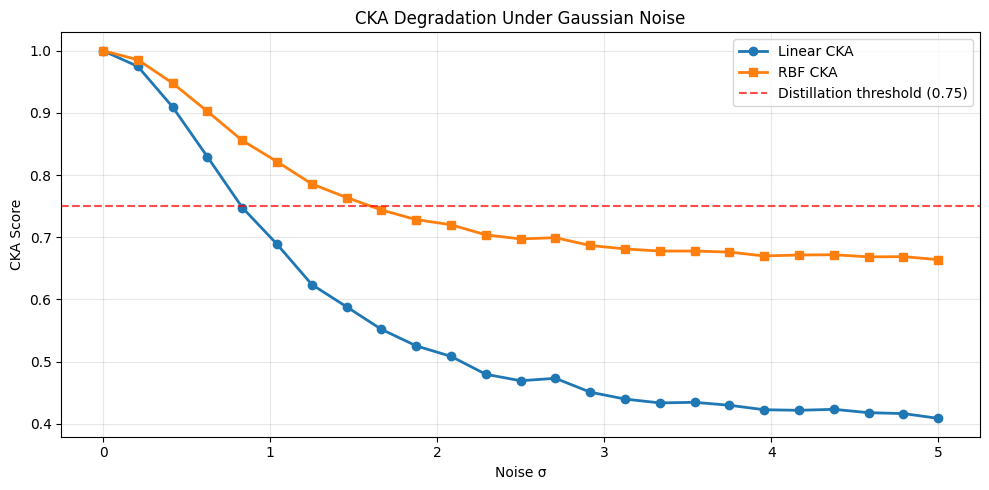

In [3]:
torch.manual_seed(42)
X = torch.randn(200, 128)
noise_levels = np.linspace(0, 5, 25)
linear_scores = []
rbf_scores = []

for sigma in noise_levels:
    Y = X + sigma * torch.randn_like(X)
    linear_scores.append(linear_cka(X, Y))
    rbf_scores.append(rbf_cka(X, Y))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(noise_levels, linear_scores, "o-", label="Linear CKA", linewidth=2)
ax.plot(noise_levels, rbf_scores, "s-", label="RBF CKA", linewidth=2)
ax.axhline(y=0.75, color="red", linestyle="--", alpha=0.7, label="Distillation threshold (0.75)")
ax.set_xlabel("Noise \u03c3")
ax.set_ylabel("CKA Score")
ax.set_title("CKA Degradation Under Gaussian Noise")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../results/cka_noise_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Minibatch CKA

For large-scale distillation we can't compute CKA on the full dataset at once. `MinibatchCKAAccumulator` computes exact CKA incrementally.

In [4]:
torch.manual_seed(42)
X_full = torch.randn(500, 64)
Y_full = X_full + 0.5 * torch.randn_like(X_full)

# Full-batch CKA (ground truth)
full_cka = linear_cka(X_full, Y_full)

# Minibatch CKA (accumulate over batches)
acc = MinibatchCKAAccumulator(d_x=64, d_y=64)
batch_size = 50
for i in range(0, 500, batch_size):
    acc.update(X_full[i:i+batch_size], Y_full[i:i+batch_size])

mb_cka = acc.compute()
print(f"Full-batch CKA:  {full_cka:.6f}")
print(f"Minibatch CKA:   {mb_cka:.6f}")
print(f"Difference:      {abs(full_cka - mb_cka):.8f}")

Full-batch CKA:  0.823229
Minibatch CKA:   0.823229
Difference:      0.00000018


## 4. Permutation Test for Statistical Significance

Is the CKA score significantly different from chance? The permutation test shuffles one representation matrix and computes a null distribution.

In [5]:
torch.manual_seed(42)
X = torch.randn(100, 32)
Y_correlated = X + 0.3 * torch.randn_like(X)
Y_random = torch.randn(100, 32)

result_corr = cka_permutation_test(X, Y_correlated, n_permutations=500)
result_rand = cka_permutation_test(X, Y_random, n_permutations=500)

print("Correlated pair:")
print(f"  CKA = {result_corr['observed_cka']:.4f}, p = {result_corr['p_value']:.4f}")
print(f"  Significant: {result_corr['p_value'] < 0.05}")

print("\nRandom pair:")
print(f"  CKA = {result_rand['observed_cka']:.4f}, p = {result_rand['p_value']:.4f}")
print(f"  Significant: {result_rand['p_value'] < 0.05}")

Correlated pair:
  CKA = 0.9354, p = 0.0000
  Significant: True

Random pair:
  CKA = 0.2287, p = 0.9020
  Significant: False


## 5. Simulated Layer-wise CKA Heatmap

Simulate a teacher (32 layers) and student (24 layers) to visualize which teacher layers map best to which student layers. This guides the distillation layer alignment strategy.

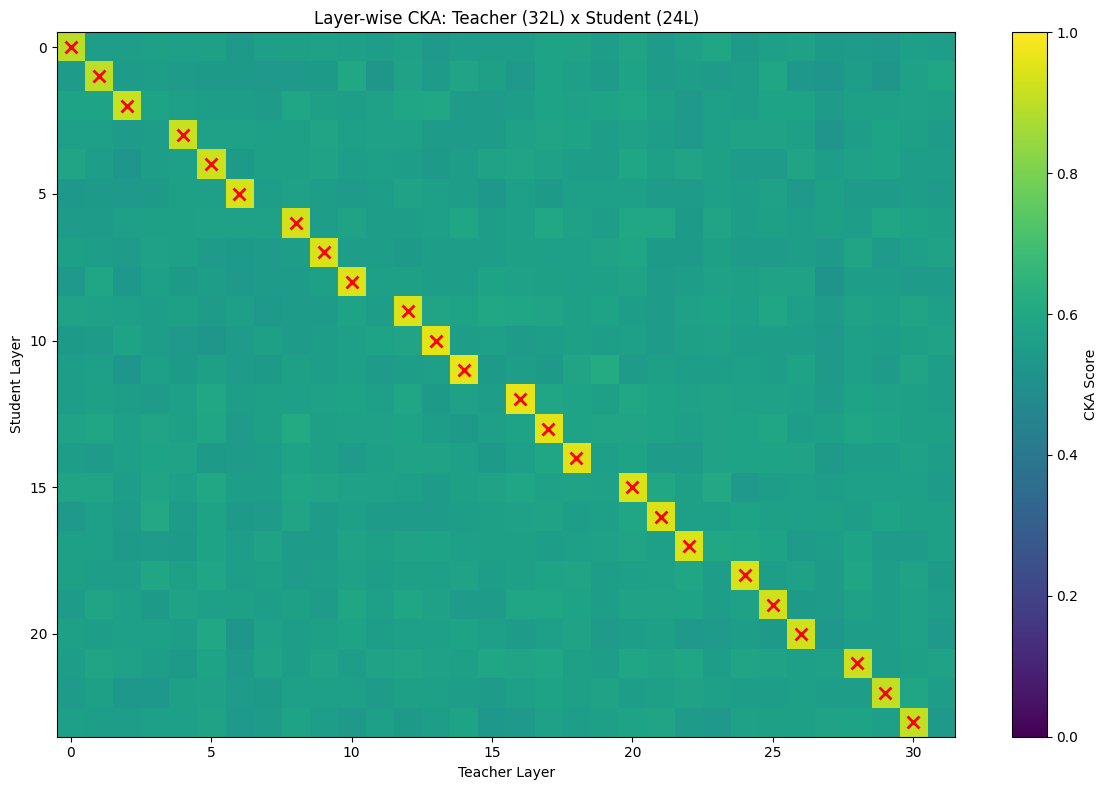

Best teacher layer for each student layer:
  Student  0 -> Teacher  0 (CKA = 0.898)
  Student  4 -> Teacher  5 (CKA = 0.923)
  Student  8 -> Teacher 10 (CKA = 0.947)
  Student 12 -> Teacher 16 (CKA = 0.962)
  Student 16 -> Teacher 21 (CKA = 0.947)
  Student 20 -> Teacher 26 (CKA = 0.926)


In [6]:
torch.manual_seed(42)
n_teacher, n_student = 32, 24
n_samples, d = 50, 64

# Simulate teacher and student activations with structured similarity
teacher_acts = {}
teacher_list = []  # keep ordered reference
for i in range(n_teacher):
    act = torch.randn(n_samples, d)
    teacher_acts[f"teacher_{i:02d}"] = act
    teacher_list.append(act)

student_acts = {}
for j in range(n_student):
    # Student layer j is most similar to teacher layer at proportional position
    t_idx = int(j * n_teacher / n_student)
    base = teacher_list[t_idx]
    noise = torch.randn_like(base) * (0.3 + 0.02 * abs(j - n_student // 2))
    student_acts[f"student_{j:02d}"] = base + noise

# Compute CKA matrix
heatmap = compute_layerwise_cka(teacher_acts, student_acts)

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(heatmap.scores.T, aspect="auto", cmap="viridis", vmin=0, vmax=1)
ax.set_xlabel("Teacher Layer")
ax.set_ylabel("Student Layer")
ax.set_title("Layer-wise CKA: Teacher (32L) x Student (24L)")
plt.colorbar(im, ax=ax, label="CKA Score")

# Mark the diagonal correspondence
for j in range(n_student):
    t_idx = int(j * n_teacher / n_student)
    ax.plot(t_idx, j, "rx", markersize=8, markeredgewidth=2)

plt.tight_layout()
plt.savefig("../results/cka_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Report best matches
print("Best teacher layer for each student layer:")
for j in range(0, n_student, 4):
    best_t = heatmap.scores[:, j].argmax()
    score = heatmap.scores[best_t, j]
    print(f"  Student {j:2d} -> Teacher {best_t:2d} (CKA = {score:.3f})")

## Key Takeaways

1. **CKA is invariant to scaling** — perfect for comparing layers with different norms
2. **Noise tolerance**: CKA stays above 0.75 threshold up to ~sigma=1.5 noise
3. **Minibatch CKA is exact** — safe to use during training
4. **Permutation test** provides statistical significance for layer matches
5. **Heatmap** reveals the structural correspondence that guides our distillation alignment